# Social Network Analysis: Repeated Characters in the Bible and Q'uran

In [54]:
# import packages
import pandas as pd
import kagglehub
import os
import itertools
import networkx as nx
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import re
import itertools
import spacy
from collections import defaultdict



## Load Textual Data

### BibleData

In [ ]:
# latest version of BibleData
path = kagglehub.dataset_download("bradystephenson/bibledata")

person_verse_path = os.path.join(path, "BibleData-PersonVerse.csv")
person_names_path = os.path.join(path, "BibleData-Person.csv")
person_relationship_path = os.path.join(path, "BibleData-PersonVerseApostolic.csv")

df_relation_pv = pd.read_csv(person_verse_path)
df_relation_names = pd.read_csv(person_names_path)
df_relation = pd.read_csv(person_relationship_path)

df_relation.head()

,person_verse_id,reference_id,person_label_id,person_id,person_label,person_label_count,person_verse_sequence,person_verse_notes
0,MAT 1:1__YHVH_1_123,MAT 1:1,YHVH_1_123,YHVH_1,Jesus,1.0,34517,NaN
1,MAT 1:1__YHVH_1_124,MAT 1:1,YHVH_1_124,YHVH_1,The Messiah,1.0,34518,NaN
2,MAT 1:1__YHVH_1_125,MAT 1:1,YHVH_1_125,YHVH_1,Son of David,1.0,34519,NaN
3,MAT 1:1__YHVH_1_126,MAT 1:1,YHVH_1_126,YHVH_1,Son of Abraham,1.0,34520,NaN
4,MAT 1:2__Abram_1_2,MAT 1:2,Abram_1_2,Abram_1,Abraham,1.0,34521,NaN


In [10]:
# gospel book matching
gospel_books = ["MAT", "MRK", "LUK", "JHN"]
# extract book code
df_relation['book'] = df_relation['reference_id'].str[:3]
# filter to four gospels only
gospels_df = df_relation[df_relation['book'].isin(gospel_books)].copy()
gospels_df = gospels_df.dropna(subset=['person_id'])

print(f"Total entries: {len(gospels_df)}")
print(f"Unique characters: {gospels_df['person_id'].nunique()}")

Total entries: 2506
Unique characters: 198


In [40]:
# all unique person labels
bible_unique_names = sorted(gospels_df['person_label'].dropna().unique())

print(bible_unique_names[:10]) 
print("characters found:", len(bible_unique_names))

['Aaron', 'Abba Father', 'Abel', 'Abiathar', 'Abihud', 'Abijah', 'Abraham', 'Abraham our father', 'Achim', 'Adam']
characters found: 254


In [12]:
verse_groups = gospels_df.groupby('reference_id')['person_id'].apply(set).reset_index()

multi_person_verses = verse_groups[verse_groups['person_id'].apply(len) > 1]
print(f"Verses with co-occurring characters: {len(multi_person_verses)}")

Verses with co-occurring characters: 392


### Qur'an Data

In [14]:
# !python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 34.9 MB/s  0:00:00eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [16]:
# Qur'an API
nlp = spacy.load("en_core_web_sm")

url = "https://api.alquran.cloud/v1/quran/en.sahih"
response = requests.get(url).json()

verses_data = []
for surah in response['data']['surahs']:
    surah_num = surah['number']
    for ayah in surah['ayahs']:
        verses_data.append({
            'reference_id': f"QURAN {surah_num}:{ayah['numberInSurah']}",
            'text': ayah['text']
        })

df_quran = pd.DataFrame(verses_data)
df_quran.head()

,reference_id,text
0,QURAN 1:1,"In the name of Allah, the Entirely Merciful, t..."
1,QURAN 1:2,"[All] praise is [due] to Allah, Lord of the wo..."
2,QURAN 1:3,"The Entirely Merciful, the Especially Merciful,"
3,QURAN 1:4,Sovereign of the Day of Recompense.
4,QURAN 1:5,It is You we worship and You we ask for help.


In [18]:
def extract_characters(text):
    doc = nlp(text)
    discovered_names = set()

    for ent in doc.ents:
        if ent.label_ == "PERSON":
            clean_name = ent.text.strip().strip("'s").title()
            if len(clean_name) > 1:
                discovered_names.add(clean_name)
                
    return list(discovered_names)

In [20]:
df_quran['characters'] = df_quran['text'].apply(extract_characters)

df_quran.head()

,reference_id,text,characters
0,QURAN 1:1,"In the name of Allah, the Entirely Merciful, t...",[]
1,QURAN 1:2,"[All] praise is [due] to Allah, Lord of the wo...",[]
2,QURAN 1:3,"The Entirely Merciful, the Especially Merciful,",[]
3,QURAN 1:4,Sovereign of the Day of Recompense.,[]
4,QURAN 1:5,It is You we worship and You we ask for help.,[]


In [23]:
all_unique_names = sorted(list(set(
    name for sublist in df_quran['characters'] for name in sublist
)))

print(all_unique_names)
print("characters found:", len(all_unique_names))

["A'Ibah", 'Aaron', 'Abraham', 'Abu Lahab', 'Adam', 'Ahmad', 'Al-Ahqaf', 'Al-Firdau', 'Al-Kawthar', 'Al-Khidh', 'Al-Lat', 'Al-Madinah', 'Al-Marwah', 'Al-Masjid Al-Aqsa', 'Al-Masjid Al-Haram', 'Angel', 'Ansar', 'Arafat', 'Arise', 'Ascendant', 'Ayn', 'Bestower', 'Blessed', 'Comfort Wherein', 'Creator', 'David', 'Dhul-Kifl', 'Dhul-Qarnayn', 'Disposer', 'Dwell', 'Elia', 'Elisha', 'Ezra', 'Fire', 'Flame', 'Gabriel', 'Gog', 'Goliath', 'Gospel', 'Hajj', 'Haman', 'Haram', 'Harut', 'Hellfire', 'Him', 'Him Isaac', 'His Messenger', 'His Messenger - Allah', 'His Messenger - He', 'His Servant', 'Hud', 'Iblee', 'Isaac', 'Ishmael', 'Jacob', 'Jesu', 'Jinn', 'Job', 'John', 'Jonah', 'Joseph', 'Kaf', 'Kill Joseph', 'Kind', 'Lam', 'Lot', 'Luqman', 'Madinah', 'Madyan', 'Magog', 'Makkah', 'Mary', 'Mary - Distinguished', 'Mary - The', 'Masjid Al-Haram', 'Messenger', 'Messiah', 'Michael', 'Muhammad', 'Nasr', 'Noah', 'O Haman', 'Our Messenger', 'Pharaoh', 'Powerful', 'Praiseworthy', 'Prevailing', 'Prophet', 'P

In [ ]:
QURAN_CHARACTER_MAP = {
    # Shared Characters
    "Jesus": "YHVH_1", "Jesu": "YHVH_1", "Said Jesu": "YHVH_1", "Messiah": "YHVH_1",
    "Abraham": "Abram_1",
    "Mary": "Mary_1", "Mary - Distinguished": "Mary_1", "Mary - The": "Mary_1",
    "Zachariah": "Zacharias_1", "Zechariah": "Zacharias_1",
    "John": "John_1",  # John the Baptist
    "Gabriel": "Gabriel_1",
    "Michael": "Michael_1",
    "Satan": "Satan_1", "Iblee": "Satan_1", # Quranic equivalent of Satan/Lucifer
    
    # Shared Ancestors
    "Moses": "Moses_1", "Said Mose": "Moses_1",
    "Aaron": "Aaron_1",
    "Adam": "Adam_1",
    "David": "David_1",
    "Elisha": "Elisha_1",
    "Ezra": "Ezra_1",
    "Isaac": "Isaac_1", "Him Isaac": "Isaac_1",
    "Ishmael": "Ishmael_1",
    "Jacob": "Jacob_1",
    "Job": "Job_1",
    "Jonah": "Jonah_1",
    "Joseph": "Joseph_1", "Kill Joseph": "Joseph_1", # Joseph the Patriarch 
    "Lot": "Lot_1",
    "Noah": "Noah_1",
    "Solomon": "Solomon_1",
    "Goliath": "Goliath_1",
    "Saul": "Saul_1",
    
    # Quran Specific Characters
    "Muhammad": "Muhammad_1", "Prophet Muhammad": "Muhammad_1",
    "Abu Lahab": "Abu_Lahab_1",
    "Dhul-Kifl": "Dhul_Kifl_1",
    "Dhul-Qarnayn": "Dhul_Qarnayn_1",
    "Haman": "Haman_1", "O Haman": "Haman_1",
    "Harut": "Harut_1",
    "Hud": "Hud_1",
    "Luqman": "Luqman_1",
    "Pharaoh": "Pharaoh_1", "Said Pharaoh": "Pharaoh_1",
    "Salih": "Salih_1",
    "Zayd": "Zayd_1"
}

In [47]:
def clean_and_resolve(raw_names):
    cleaned_ids = set()
    for name in raw_names:
        if name in QURAN_CHARACTER_MAP:
            cleaned_ids.add(QURAN_CHARACTER_MAP[name])
    return list(cleaned_ids)
# resolution mapping
df_quran['cleaned_characters'] = df_quran['characters'].apply(clean_and_resolve)
# filter to verses w/ characters
df_quran_clean = df_quran[df_quran['cleaned_characters'].map(len) > 0].copy()

# extracting the surah number
df_quran_clean['surah_number'] = df_quran_clean['reference_id'].str.extract(r'QURAN (\d+):').astype(int)

df_quran_clean.head()

,reference_id,text,characters,cleaned_characters,surah_number
29,QURAN 2:23,And if you are in doubt about what We have sen...,[Muhammad],[Muhammad_1],2
36,QURAN 2:30,"And [mention, O Muhammad], when your Lord said...",[Muhammad],[Muhammad_1],2
37,QURAN 2:31,And He taught Adam the names - all of them. Th...,[Adam],[Adam_1],2
43,QURAN 2:37,"Then Adam received from his Lord [some] words,...",[Adam],[Adam_1],2
68,QURAN 2:62,"Indeed, those who believed and those who were ...","[Prophet Muhammad, Sabean]",[Muhammad_1],2


### Shared Character Mapping

In [48]:
# BibleData Characters
bible_characters = sorted(gospels_df['person_id'].dropna().unique())
print(bible_characters) 
print(len(bible_characters))

['Aaron_1', 'Abel_1', 'Abiathar_1', 'Abihud_2', 'Abijah_5', 'Abijam_1', 'Abram_1', 'Achim_1', 'Adam_1', 'Addi_1', 'Admin_1', 'Ahaz_1', 'Alexander_1', 'Alphaeus_1', 'Amminadab_1', 'Amon_2', 'Amos_2', 'Andrew_1', 'Anna_1', 'Annas_1', 'Archelaus_1', 'Arpachshad_1', 'Asa_1', 'Azariah_3', 'Azor_1', 'Barabbas_1', 'Bartholomew_1', 'Bartimaeus_1', 'Bathsheba_1', 'Berechiah_6', 'Boaz_1', 'Caesar Augustus_1', 'Caesar_1', 'Caiaphas_1', 'Cainan_1', 'Chuza_1', 'Cleopas_1', 'Clopas_1', 'Cosam_1', 'Daniel_2', 'Daughter_1', 'David_1', 'Eber_1', 'Eleazar_9', 'Eli_2', 'Eliakim_4', 'Eliakim_5', 'Eliezer_9', 'Elijah_1', 'Elisha_1', 'Eliud_1', 'Elizabeth_1', 'Elmadam_1', 'Enoch_2', 'Enosh_1', 'Er_3', 'Gabriel_1', 'Herod_1', 'Herod_2', 'Herodias_1', 'Hesli_1', 'Hezekiah_1', 'Hezron_2', 'Isaac_1', 'Isaiah_1', 'Jacob_1', 'Jacob_2', 'Jairus_1', 'James_1', 'James_2', 'James_3', 'James_4', 'Jannai_1', 'Jared_1', 'Jehoiachin_1', 'Jehoram_1', 'Jehoshaphat_3', 'Jeremiah_6', 'Jesse_1', 'Joanan_1', 'Joanna_1', 'Joda_

In [49]:
# Qur'an Data Characters
quran_characters = sorted(list(set(
    name for sublist in df_quran_clean['cleaned_characters'] for name in sublist
)))
print(quran_characters)
print(len(quran_characters))

['Aaron_1', 'Abram_1', 'Abu_Lahab_1', 'Adam_1', 'David_1', 'Dhul_Kifl_1', 'Dhul_Qarnayn_1', 'Elisha_1', 'Ezra_1', 'Gabriel_1', 'Goliath_1', 'Haman_1', 'Harut_1', 'Hud_1', 'Isaac_1', 'Ishmael_1', 'Jacob_1', 'Job_1', 'John_1', 'Jonah_1', 'Joseph_1', 'Lot_1', 'Luqman_1', 'Mary_1', 'Michael_1', 'Moses_1', 'Muhammad_1', 'Noah_1', 'Pharaoh_1', 'Salih_1', 'Satan_1', 'Saul_1', 'Solomon_1', 'YHVH_1', 'Zayd_1']
35


In [52]:
# character lists from both
gospel_nodes = set(gospels_df['person_id'].unique())
quran_nodes = set()
for char_list in df_quran_clean['cleaned_characters']:
    quran_nodes.update(char_list)

# intersection
shared_nodes = gospel_nodes.intersection(quran_nodes)

print(f"Gospel: {len(gospel_nodes)}")
print(f"Qur'an: {len(quran_nodes)}")
print(f"Intersection: {len(shared_nodes)}")
print("Shared names list:", shared_nodes)

Gospel: 198
Qur'an: 35
Intersection: 18
Shared names list: {'John_1', 'Satan_1', 'Noah_1', 'YHVH_1', 'Elisha_1', 'Lot_1', 'Gabriel_1', 'Aaron_1', 'David_1', 'Isaac_1', 'Solomon_1', 'Joseph_1', 'Mary_1', 'Moses_1', 'Jacob_1', 'Adam_1', 'Abram_1', 'Jonah_1'}


### Shared Characters Between Bible and Qur'an

Link: https://en.wikipedia.org/wiki/List_of_people_in_both_the_Bible_and_the_Quran

In [57]:
def build_network(df, text_col, group_col):
    G = nx.Graph()
    edge_weights = defaultdict(int)
    
    # group by book/surah
    for _, group in df.groupby(group_col):
        for characters in group[text_col]:
            # remove duplicates within the same verse
            unique_chars = sorted(list(set(characters)))
            # link between every pair of characters in this verse
            for i in range(len(unique_chars)):
                for j in range(i + 1, len(unique_chars)):
                    char1, char2 = unique_chars[i], unique_chars[j]
                    edge_weights[(char1, char2)] += 1
    # add nodes and weighted edges to the NetworkX graph
    for (node1, node2), weight in edge_weights.items():
        G.add_edge(node1, node2, weight=weight)
        
    return G

# Gospels Graph
gospel_verse_df = gospels_df.groupby(['book', 'reference_id'])['person_id'].apply(list).reset_index()
G_gospels = build_network(gospel_verse_df, 'person_id', 'book')

# Qur'an Graph
G_quran = build_network(df_quran_clean, 'cleaned_characters', 'surah_number')

print("GOSPELS NETWORK")
print(f"Nodes: {G_gospels.number_of_nodes()}")
print(f"Edges: {G_gospels.number_of_edges()}")

print("\nQURAN NETWORK")
print(f"Nodes: {G_quran.number_of_nodes()}")
print(f"Edges: {G_quran.number_of_edges()}")

GOSPELS NETWORK
Nodes: 189
Edges: 465

QURAN NETWORK
Nodes: 30
Edges: 79


### Comparative Analysis

In [62]:
def calculate_global_topology(G, name):
    # density
    density = nx.density(G)
    # average clustering coefficient
    avg_clustering = nx.average_clustering(G)
    
    # largest connected component
    if len(G) > 0 and nx.is_connected(G):
        avg_path = nx.average_shortest_path_length(G)
        diameter = nx.diameter(G)
    elif len(G) > 0:
        # disconnected
        largest_cc = max(nx.connected_components(G), key=len)
        subgraph = G.subgraph(largest_cc)
        avg_path = nx.average_shortest_path_length(subgraph)
        diameter = nx.diameter(subgraph)
    else:
        avg_path, diameter = 0, 0

    metrics = {
        "Network": name,
        "Nodes": G.number_of_nodes(),
        "Edges": G.number_of_edges(),
        "Density": round(density, 4),
        "Avg. Clustering Coeff": round(avg_clustering, 4),
        "Avg. Path Length": round(avg_path, 4),
        "Diameter": diameter
    }
    return metrics

metrics_gospels = calculate_global_topology(G_gospels, "Gospels")
metrics_quran = calculate_global_topology(G_quran, "Quran")

# display resulsts
df_topology = pd.DataFrame([metrics_gospels, metrics_quran])
print(df_topology.to_markdown(index=False))

| Network   |   Nodes |   Edges |   Density |   Avg. Clustering Coeff |   Avg. Path Length |   Diameter |
|:----------|--------:|--------:|----------:|------------------------:|-------------------:|-----------:|
| Gospels   |     189 |     465 |    0.0262 |                  0.745  |             3.4567 |          8 |
| Quran     |      30 |      79 |    0.1816 |                  0.4228 |             2.4471 |          6 |


In [63]:
def get_centrality_df(G, prefix):

    deg = nx.degree_centrality(G)
    bet = nx.betweenness_centrality(G)
    # eigenvector centrality
    try:
        eig = nx.eigenvector_centrality(G, max_iter=1000)
    except nx.PowerIterationFailedConvergence:
        eig = nx.eigenvector_centrality_numpy(G)
        
    df = pd.DataFrame({
        'character': list(deg.keys()),
        f'{prefix}_Degree': list(deg.values()),
        f'{prefix}_Betweenness': list(bet.values()),
        f'{prefix}_Eigenvector': list(eig.values())
    })
    
    # round
    for col in df.columns:
        if col != 'character':
            df[col] = df[col].round(4)
            
    return df

df_gospel_cent = get_centrality_df(G_gospels, "Gospel")
df_quran_cent = get_centrality_df(G_quran, "Quran")

df_overlap = pd.merge(df_gospel_cent, df_quran_cent, on='character', how='inner')
print(f"Found {len(df_overlap)} shared characters")
print(df_overlap.sort_values(by='Quran_Degree', ascending=False).head(10))

Found 16 shared characters
    character  Gospel_Degree  Gospel_Betweenness  Gospel_Eigenvector  \
10     Noah_1         0.0266              0.0291              0.0422   
7     Abram_1         0.0585              0.0355              0.0953   
6     David_1         0.0638              0.0660              0.0824   
1      YHVH_1         0.3032              0.3584              0.4587   
0   Solomon_1         0.0479              0.1018              0.0537   
4     Jacob_1         0.0426              0.0270              0.0625   
9     Isaac_1         0.0319              0.0166              0.0600   
13    Aaron_1         0.0213              0.0000              0.0174   
5    Joseph_1         0.0053              0.0000              0.0055   
12     Mary_1         0.0745              0.0444              0.1088   

    Quran_Degree  Quran_Betweenness  Quran_Eigenvector  
10        0.4828             0.1818             0.3340  
7         0.4483             0.1177             0.3309  
6        

### Network Graph Visualizations

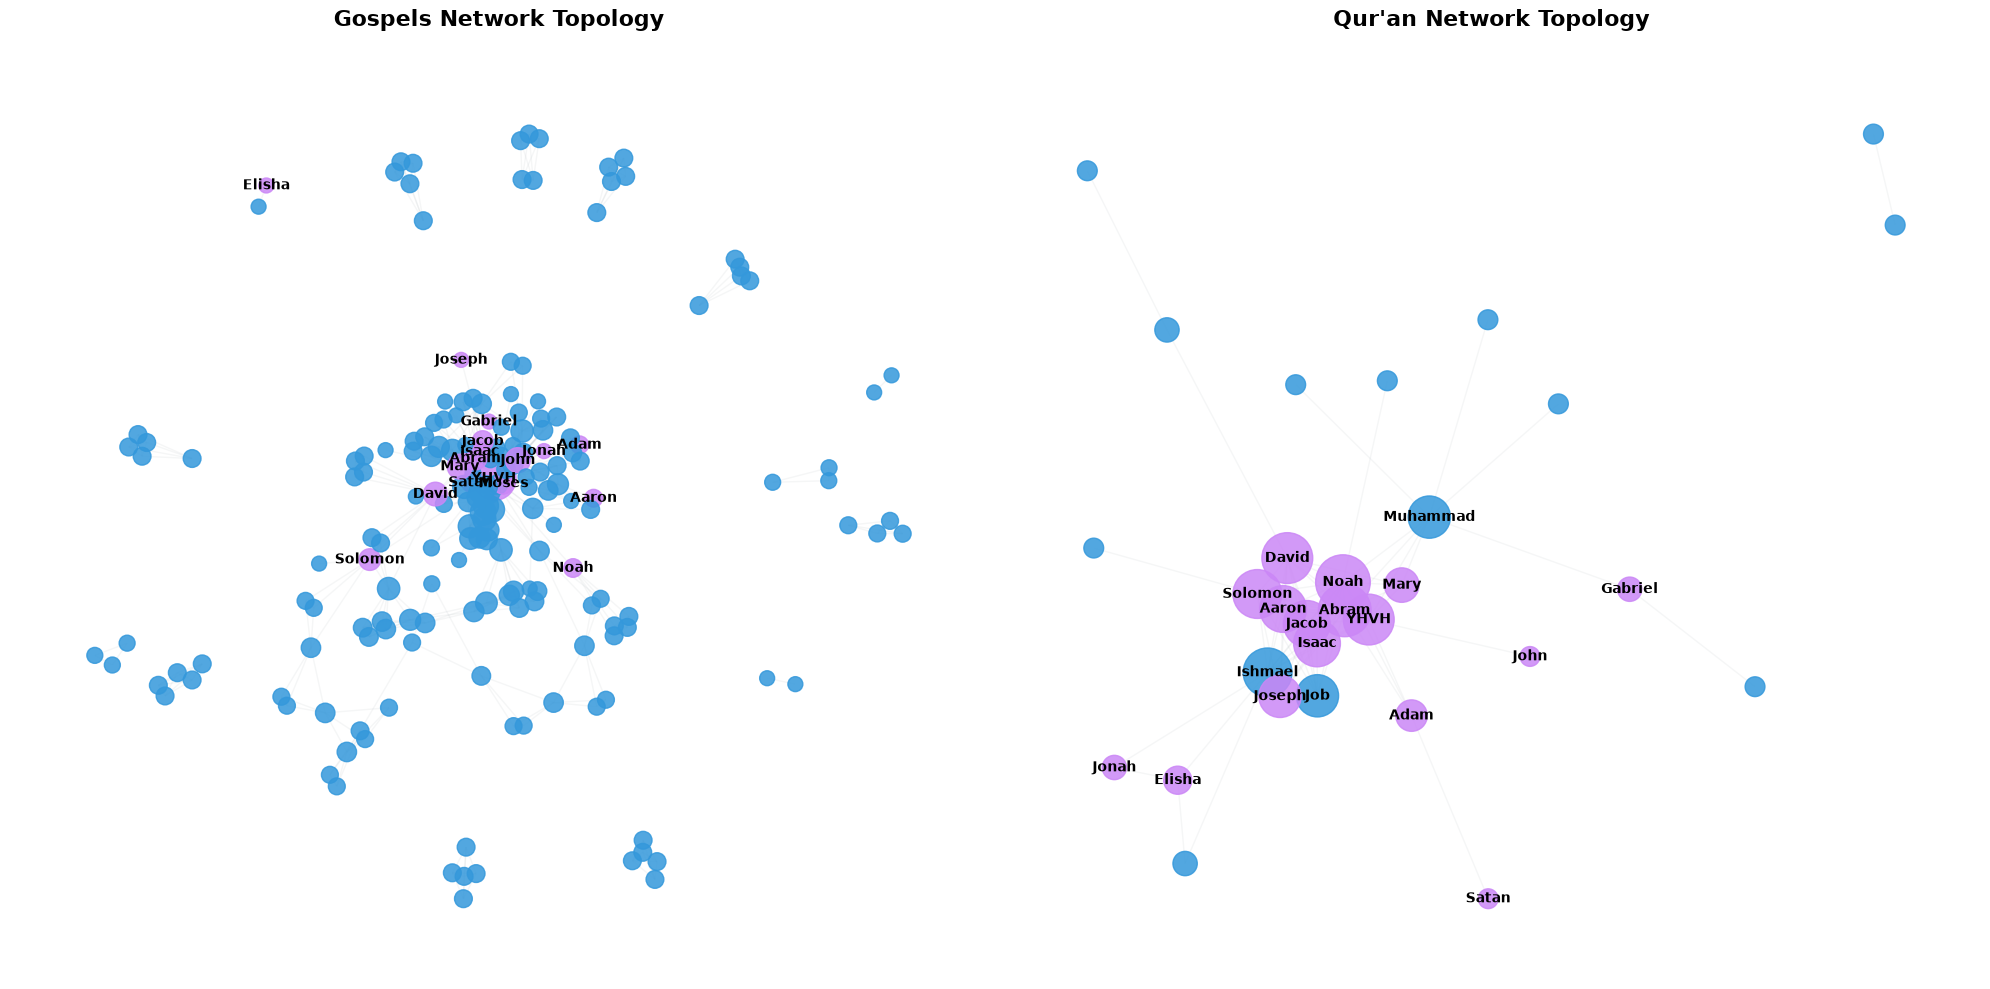

In [ ]:
def plot_religious_networks(G_gosp, G_qur, shared_nodes):
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    networks = [
        {"G": G_gosp, "ax": axes[0], "title": "Gospels Network Topology", "k": 0.15},
        {"G": G_qur, "ax": axes[1], "title": "Qur'an Network Topology", "k": 0.35}
    ]
    
    for net in networks:
        G = net["G"]
        ax = net["ax"]
        # force directed layout
        pos = nx.spring_layout(G, k=net["k"], seed=42)
        # highlight shared nodes
        node_colors = []
        for node in G.nodes():
            if node in shared_nodes:
                node_colors.append("#CB87F6") 
            else:
                node_colors.append('#3498DB') 
                
        # scale by degree centrality
        deg_centrality = nx.degree_centrality(G)
        node_sizes = [v * 3000 + 100 for v in deg_centrality.values()]
        
        # edges
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15, edge_color='#BDC3C7')
        # nodes
        nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes, alpha=0.85)
        
        # label only highly central nodes
        labels = {}
        for node in G.nodes():
            if node in shared_nodes or deg_centrality[node] > 0.1:
                # names
                labels[node] = node.split('_')[0]
                
        nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=10, font_weight='bold')
        
        ax.set_title(net["title"], fontsize=16, fontweight='bold', pad=20)
        ax.axis('off')
        
    plt.tight_layout()
    # plt.savefig("gospels_vs_quran_network.png", dpi=300)
    plt.show()

plot_religious_networks(G_gospels, G_quran, shared_nodes)